In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, norm, probplot

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\MATHS PROJECTS\Final PR\StudentsPerformance.csv")

print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [4]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000

In [5]:
mean_math = df['math score'].mean()
median_math = df['math score'].median()
mode_math = df['math score'].mode()[0]

print("Mean :", mean_math)
print("Median :", median_math)
print("Mode :", mode_math)

Mean : 66.089
Median : 66.0
Mode : 65


In [6]:
range_reading = df['reading score'].max() - df['reading score'].min()

variance_reading = df['reading score'].var()

std_reading = df['reading score'].std()

print("Range :", range_reading)
print("Variance :", variance_reading)
print("Standard Deviation :", std_reading)

Range : 83
Variance : 213.16560460460462
Standard Deviation : 14.600191937252216


In [7]:
df['Pass_Fail'] = np.where(df['math score'] >= 35, 1, 0)

print(df[['math score', 'Pass_Fail']].head())

   math score  Pass_Fail
0          72          1
1          69          1
2          90          1
3          47          1
4          76          1


In [8]:
prob_pass = (df['Pass_Fail'] == 1).mean()

print("Probability of Passing :", prob_pass)

Probability of Passing : 0.978


In [9]:
df['Math_More_70'] = df['math score'] > 70

print(df[['math score', 'Math_More_70']].head())

   math score  Math_More_70
0          72          True
1          69         False
2          90          True
3          47         False
4          76          True


In [10]:
contingency_table = pd.crosstab(
    df['Pass_Fail'],
    df['Math_More_70']
)

print(contingency_table)

Math_More_70  False  True 
Pass_Fail                 
0                22      0
1               587    391


In [11]:
conditional_probability = len(
    df[(df['Pass_Fail'] == 1) & (df['Math_More_70'] == True)]
) / len(df[df['Math_More_70'] == True])

print("Conditional Probability :", conditional_probability)

Conditional Probability : 1.0


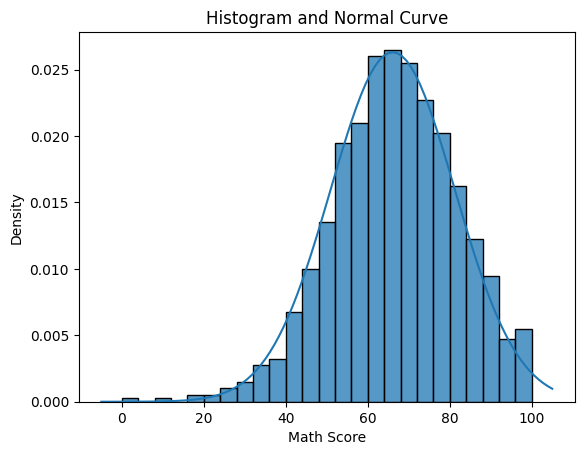

In [12]:
mean = df['math score'].mean()
std = df['math score'].std()

sns.histplot(df['math score'], stat='density')

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mean, std)

plt.plot(x, p)

plt.title("Histogram and Normal Curve")
plt.xlabel("Math Score")
plt.ylabel("Density")

plt.show()

In [13]:
reading_skewness = skew(df['reading score'])

reading_kurtosis = kurtosis(df['reading score'])

print("Skewness :", reading_skewness)

print("Kurtosis :", reading_kurtosis)

Skewness : -0.25871569927829347
Kurtosis : -0.07391861478331307


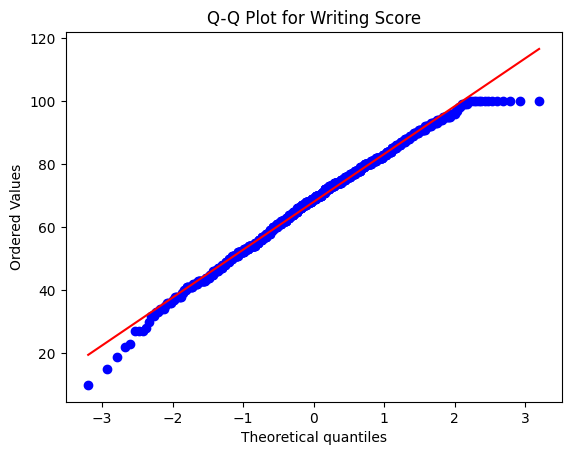

In [14]:
probplot(df['writing score'], dist="norm", plot=plt)

plt.title("Q-Q Plot for Writing Score")

plt.show()

In [15]:
math_vector = df['math score'].head().values

reading_vector = df['reading score'].head().values

print("Math Vector :", math_vector)

print("Reading Vector :", reading_vector)

Math Vector : [72 69 90 47 76]
Reading Vector : [72 90 95 57 78]


In [16]:
dot_product = np.dot(math_vector, reading_vector)

print("Dot Product :", dot_product)

Dot Product : 28551


In [17]:
norm1 = np.linalg.norm(math_vector, 1)

norm2 = np.linalg.norm(math_vector, 2)

print("Norm 1 :", norm1)

print("Norm 2 :", norm2)

Norm 1 : 354.0
Norm 2 : 161.33815419794539


In [18]:
cos_theta = np.dot(math_vector, reading_vector) / (
    np.linalg.norm(math_vector) * np.linalg.norm(reading_vector)
)

angle_radian = np.arccos(cos_theta)

angle_degree = np.degrees(angle_radian)

print("Angle in Radian :", angle_radian)

print("Angle in Degree :", angle_degree)

Angle in Radian : 0.1016528510927943
Angle in Degree : 5.824279343088932


In [19]:
print("1. Average math score is around 66.")
print("2. Most students passed the exam.")
print("3. Students scoring above 70 have very high pass probability.")
print("4. Reading score distribution is close to normal.")
print("5. Math and Reading scores show strong similarity.")

1. Average math score is around 66.
2. Most students passed the exam.
3. Students scoring above 70 have very high pass probability.
4. Reading score distribution is close to normal.
5. Math and Reading scores show strong similarity.


1. Mean, Median, and Mode.
- Mean is the average of all values. It is calculated by adding all numbers and dividing by the total count.
- Median is the middle value when data is arranged in order.
- Mode is the value that appears most frequently.
- Example: If marks are 50, 60, 60, 70, 80 → Mean = 64, Median = 60, Mode = 60.

2. Variance vs Standard Deviation.
- Variance measures how far data values spread from the mean.
- Standard Deviation is the square root of variance and is easier to understand because it uses the same unit as the data.
- A low standard deviation means data points are close to the mean, while a high value means they are spread out.
- Both are used to measure variability in data analysis.

3. Normal Distribution.
- A Normal Distribution is a bell-shaped probability distribution where most values are near the mean.
- It is symmetric, meaning both sides are equal.
- Mean, median, and mode are equal in a normal distribution.
- Example: Heights of students in a school often follow a normal distribution.

4. Skewness and Kurtosis.
- Skewness measures whether data is tilted to the left or right.
- Positive skew means the tail is longer on the right side, while negative skew means it is longer on the left.
- Kurtosis measures how peaked or flat the distribution is.
- High kurtosis means more extreme values (outliers).

5. Probability and Empirical vs Theoretical Probability.
- Probability is the chance of an event happening. Its value ranges from 0 to 1.
- Theoretical Probability is based on formulas and expected outcomes. Example: Probability of getting head in a coin toss = 1/2.
- Empirical Probability is based on actual experiments or observations. Example: If a coin gives 45 heads in 100 tosses, empirical    probability = 45/100 = 0.45.
- Theoretical uses mathematics, while empirical uses real data.

6. Independent vs Dependent Events.
- Independent Events are events where one event does not affect the other.
- Example: Tossing a coin and rolling a dice.
- Dependent Events are events where one event affects another.
- Example: Picking two cards from a deck without replacement.

7. Bayes Theorem in Daily Life.
- Bayes Theorem helps update probabilities when new information is received.
- It is commonly used in medical testing, spam email filtering, and prediction systems.
- Example: If a medical test result is positive, Bayes Theorem helps calculate the actual probability that the person has the disease.
- It improves decision-making using prior knowledge.

8. Eigenvalue and Eigenvector.
- An Eigenvector is a vector whose direction does not change after a matrix transformation.
- An Eigenvalue is the factor by which the eigenvector is scaled.
- They are widely used in machine learning, computer graphics, and data compression.
- Example: In facial recognition systems, eigenvectors help identify important features of faces.